In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("flood_dataset_classification.csv")
df.head()

,Disaster Type,Latitude,Longitude,Total Deaths,Total Affected,duration,time,Rainfall,Elevation,Slope,distance,occured
0,0,52.6717,-0.2995,300.0,3000.0,0.0,1900,1383.125626,11.0,1.788207,0.0,1
1,0,35.6897,139.6920,1379.0,13790.0,0.0,1909,1383.125626,49.0,24.356508,0.0,1
2,0,39.9050,116.3910,100000.0,1000000.0,0.0,1909,580.345856,55.0,8.374380,0.0,1
3,0,23.1288,113.2590,0.0,3000000.0,0.0,1912,2993.401777,7.0,12.917221,0.0,1
4,0,39.1467,117.2060,0.0,635000.0,0.0,1913,1383.125626,3.0,1.513093,0.0,1


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6237 entries, 0 to 6236
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Disaster Type   6237 non-null   int64  
 1   Latitude        6237 non-null   float64
 2   Longitude       6237 non-null   float64
 3   Total Deaths    6237 non-null   float64
 4   Total Affected  6237 non-null   float64
 5   duration        6237 non-null   float64
 6   time            6237 non-null   int64  
 7   Rainfall        6237 non-null   float64
 8   Elevation       6237 non-null   float64
 9   Slope           6237 non-null   float64
 10  distance        6237 non-null   float64
 11  occured         6237 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 584.8 KB


Disaster Type     0
Latitude          0
Longitude         0
Total Deaths      0
Total Affected    0
duration          0
time              0
Rainfall          0
Elevation         0
Slope             0
distance          0
occured           0
dtype: int64

In [4]:
df.fillna(df.mean(), inplace=True)

In [5]:
sns.histplot(df['Annual_Rainfall'])
plt.show()

KeyError: 'Annual_Rainfall'

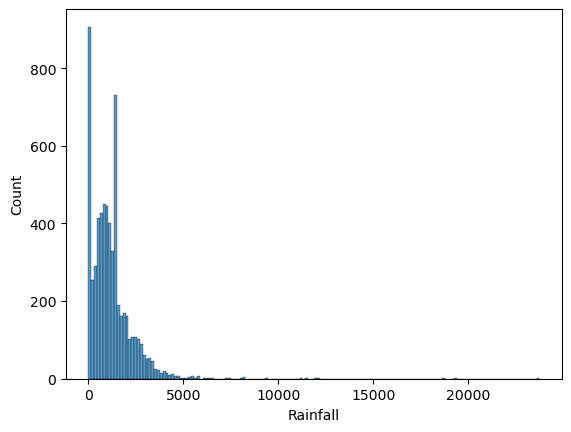

In [6]:
sns.histplot(df['Rainfall'])
plt.show()

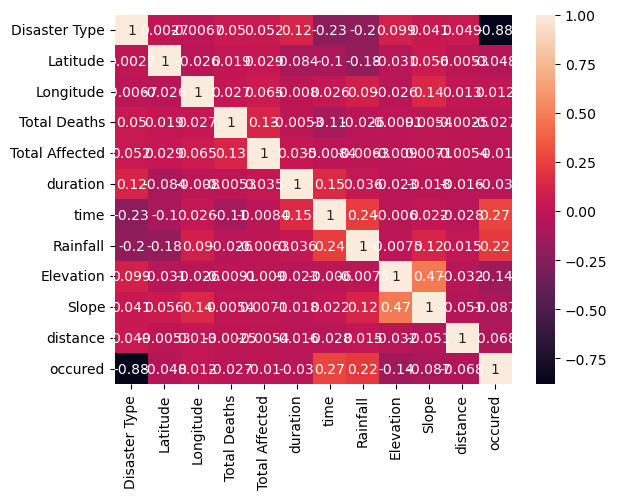

In [7]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [8]:
X = df.drop("Flood", axis=1)
y = df["Flood"]

KeyError: "['Flood'] not found in axis"

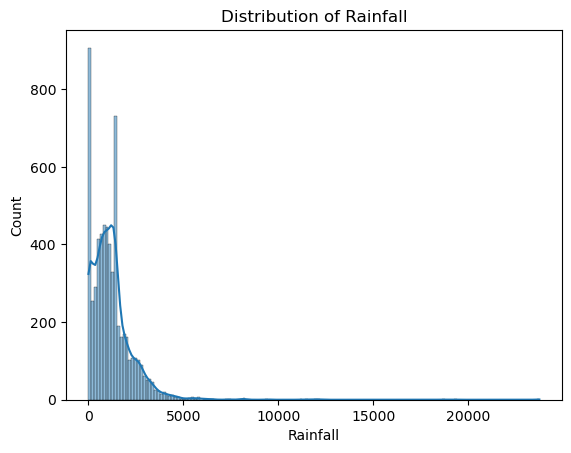

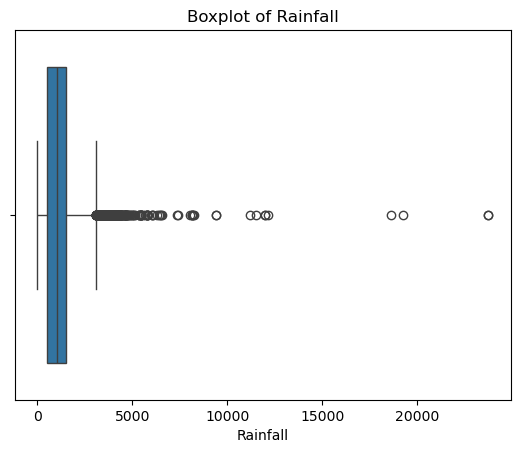

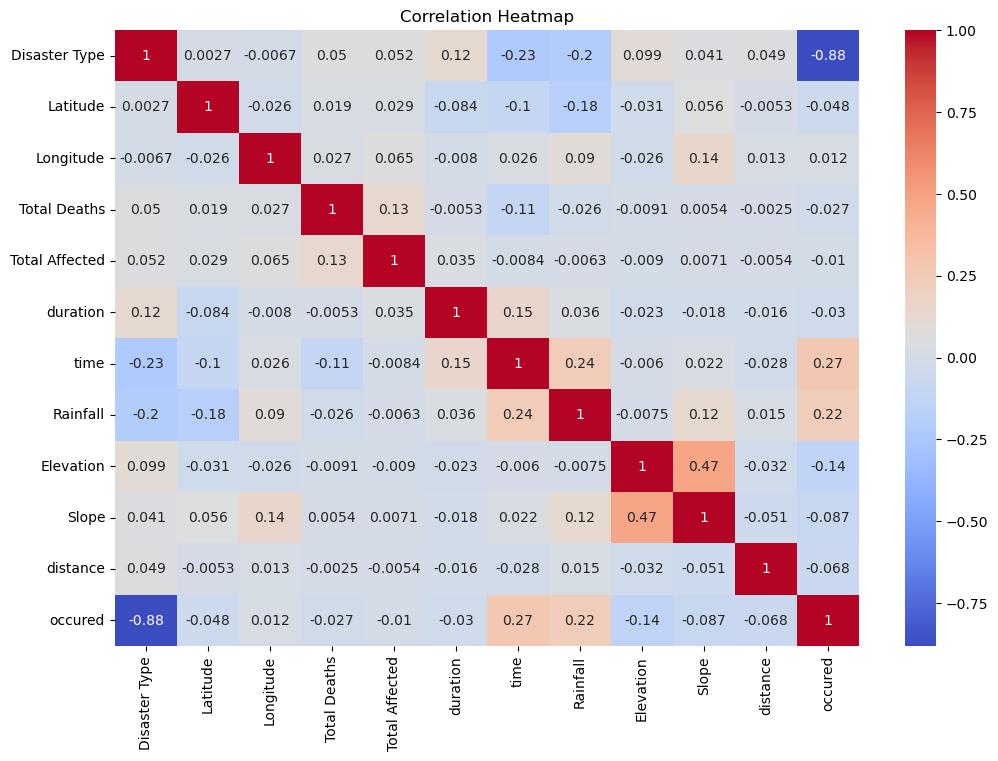

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot for Rainfall
sns.histplot(df['Rainfall'], kde=True)
plt.title("Distribution of Rainfall")
plt.show()

# Boxplot for Rainfall (to check outliers)
sns.boxplot(x=df['Rainfall'])
plt.title("Boxplot of Rainfall")
plt.show()

# Heatmap for correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df = df.drop("Disaster Type", axis=1)

In [11]:
X = df.drop("occured", axis=1)
y = df["occured"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
import joblib
joblib.dump(scaler, "transform.save")

['transform.save']

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7700320512820513
[[265 118]
 [169 696]]
              precision    recall  f1-score   support

           0       0.61      0.69      0.65       383
           1       0.86      0.80      0.83       865

    accuracy                           0.77      1248
   macro avg       0.73      0.75      0.74      1248
weighted avg       0.78      0.77      0.77      1248



In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8469551282051282
[[244 139]
 [ 52 813]]
              precision    recall  f1-score   support

           0       0.82      0.64      0.72       383
           1       0.85      0.94      0.89       865

    accuracy                           0.85      1248
   macro avg       0.84      0.79      0.81      1248
weighted avg       0.84      0.85      0.84      1248



In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.7900641025641025
[[203 180]
 [ 82 783]]
              precision    recall  f1-score   support

           0       0.71      0.53      0.61       383
           1       0.81      0.91      0.86       865

    accuracy                           0.79      1248
   macro avg       0.76      0.72      0.73      1248
weighted avg       0.78      0.79      0.78      1248



In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8285256410256411
[[214 169]
 [ 45 820]]
              precision    recall  f1-score   support

           0       0.83      0.56      0.67       383
           1       0.83      0.95      0.88       865

    accuracy                           0.83      1248
   macro avg       0.83      0.75      0.78      1248
weighted avg       0.83      0.83      0.82      1248



In [19]:
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("KNN:", accuracy_score(y_test, knn_pred))
print("Gradient Boosting:", accuracy_score(y_test, gb_pred))

Decision Tree: 0.7700320512820513
Random Forest: 0.8469551282051282
KNN: 0.7900641025641025
Gradient Boosting: 0.8285256410256411


In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
import joblib

joblib.dump(dt, "floods.save")

['floods.save']

In [22]:
joblib.dump(scaler, "transform.save")

['transform.save']